In [1]:
import pickle
import numpy as np
from astropy.cosmology import Flatw0waCDM
from matplotlib import pyplot as plt
import corner
import matplotlib.lines as mlines

from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
from pdspl_utils.plotting import plot_dspl_corner

POSTERIOR_DIRECTORY = '../data/posteriors/forecast_w0waCDM_free_scatter'
FIGURE_DIRECTORY = '../figures/forecasts/w0waCDM_free_scatter'

%load_ext autoreload
%autoreload 2

## Prepare Datasets for the Forecast

In [2]:
# Load the pdspl_samples object
with open('../data/samples/pdspl_samples_with_pairs.pkl', 'rb') as f:
    pdspl_samples = pickle.load(f)

# --- 1. CONFIGURATION & TRUTH ---
truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16,
    'beta_c0': None, 'beta_c1': None  # Set to None so corner plots omit the varying truth lines
}

# Fix h0 globally; we will fix beta_c2 dynamically below
fixed_params = {'h0': 70.0}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

In [3]:
# --- 2. INITIALIZE SCENARIOS (LSST Y10 ONLY) ---
scenarios = {}

key = 'lsst_y10'
scenarios[key] = {
    'name': f"PDSPL ({pdspl_samples[key]['name']})",
    'down_sampling': len(pdspl_samples[key]['pairs_analysis']['pairs_table']) / 2000, 
    'num_lenses': len(pdspl_samples[key]['pairs_analysis']['pairs_table']),
    'color': '#2ca02c', # standard green for LSST Y10
    'coeffs': pdspl_samples[key]['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs'],
    'pairs_table': pdspl_samples[key]['pairs_analysis']['pairs_table'],
    'pairs_table_with_errors': pdspl_samples[key]['pairs_analysis']['pairs_table_with_errors'],
    'redshift_error_rel': 0.03, # photo-z
    'backend_path': POSTERIOR_DIRECTORY + f"/{key}.h5"
}

In [4]:
# --- 3. GENERATE MOCK DATASETS ---
print(f"{'SCENARIO':<60} | {'N_LENS':<10} | {'STATUS'}")
print("-" * 85)

sc = scenarios[key]
num_samples = int(sc['num_lenses'] / sc['down_sampling'])
kwargs_list = []

# Generation from PDSPL tables
pairs_table = sc['pairs_table']
pairs_table_with_errors = sc['pairs_table_with_errors']
coeffs = sc['coeffs']
random_indices = np.random.choice(len(pairs_table), size=num_samples, replace=False)

for i in random_indices:
    z_lens = pairs_table["z_D"][i]
    z1 = pairs_table["z_S1"][i]
    z2 = pairs_table["z_S2"][i]
    
    dissimilarity = pairs_table_with_errors['dissimilarity'][i]
    sigma_beta_intrinsic = np.polyval(coeffs, dissimilarity)
    
    sigma_beta_meas, sigma_beta_los = 0.01, 0.01
    sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
    
    kwargs_list.append(draw_lens_from_given_zs(
        z_lens=z_lens, z1=z1, z2=z2,
        lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
        gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
        sigma_beta_intrinsic=sigma_beta_intrinsic,
        sigma_meas_rel=sigma_meas_rel,
        dissimilarity=dissimilarity,
        down_sampling=sc['down_sampling'], 
        with_noise=False, # For ASIMOV inference
        cosmo=cosmo_true, 
        redshift_error_rel=sc['redshift_error_rel']
    ))
        
sc['kwargs_list'] = kwargs_list
print(f"{sc['name']:<60} | {num_samples:<10} | GENERATED")

original_keys = list(scenarios.keys())



SCENARIO                                                     | N_LENS     | STATUS
-------------------------------------------------------------------------------------
PDSPL (LSST Y10)                                             | 2000       | GENERATED


## Run the Forecast Inference

In [5]:
# --- 1. INFERENCE SETTINGS ---
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16,
    'beta_c0': 0.0, 'beta_c1': 0.0 # Will be updated dynamically
}

my_spreads = {
    'om': 0.1, 'w0': 0.1, 'wa': 0.1,
    'lambda_int': 0.1, 'lambda_sigma': 0.01,
    'gamma_pl': 0.1, 'gamma_sigma': 0.01,
    'beta_c0': 0.01, 'beta_c1': 0.1
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5),
    'beta_c0': ('uniform', -1.0, 1.0),
    'beta_c1': ('uniform', -5.0, 5.0)
}

param_labels = None 

## Uniform Prior Forecast

In [6]:
# --- 2. EXECUTION: UNIFORM PRIOR ---
print("\n--- Starting MCMC Samplers (Uniform Prior) ---")
sc = scenarios['lsst_y10']
print(f"\nRunning Inference for: {sc['name']}")

# Extract coefficients to set our initial guesses and fix the quadratic term
coeffs = sc.get('coeffs', [0.0])
c0, c1, c2 = 0.0, 0.0, 0.0
if len(coeffs) == 1: c0 = coeffs[0]
elif len(coeffs) == 2: c1, c0 = coeffs
elif len(coeffs) >= 3: c2, c1, c0 = coeffs[-3:]

fixed_params_sc = fixed_params.copy()
fixed_params_sc['beta_c2'] = c2 # We ONLY fix the quadratic term

# Dynamically assign the starting guess for the sampled scatter params
initial_guess_sc = my_guess.copy()
initial_guess_sc['beta_c0'] = c0
initial_guess_sc['beta_c1'] = c1

samples, labels = run_dspl_inference(
    sc['kwargs_list'],
    n_walkers=64,
    n_steps=2000,
    n_burn=500,
    initial_guess=initial_guess_sc,
    fixed_params=fixed_params_sc,
    initial_scatter=my_spreads,
    priors=my_priors,
    backend_path=sc['backend_path']
)

sc['samples'] = samples
param_labels = labels # Saves labels for plotting step
print(f"{sc['name']} | INFERENCE COMPLETE")


--- Starting MCMC Samplers (Uniform Prior) ---

Running Inference for: PDSPL (LSST Y10)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0', 'beta_c1']


100%|██████████| 2000/2000 [10:35<00:00,  3.15it/s]

PDSPL (LSST Y10) | INFERENCE COMPLETE


## Omega_m 0.05 Prior Forecast

In [7]:
# --- 3. EXECUTION: OMEGA_M PRIOR ---
print("\n--- Starting MCMC Samplers for Forecast with Prior on Omega_m ---")

key_with_prior = 'lsst_y10_om_prior'
scenarios[key_with_prior] = scenarios['lsst_y10'].copy()
scenarios[key_with_prior]['name'] += ' + $\\Omega_m$ Prior'
scenarios[key_with_prior]['color'] = '#3e1d03' # darker color to distinguish
scenarios[key_with_prior]['backend_path'] = POSTERIOR_DIRECTORY + f"/{key_with_prior}.h5"

my_priors_om = my_priors.copy()
my_priors_om['om'] = ('gaussian', 0.3, 0.05)

sc_prior = scenarios[key_with_prior]
print(f"\nRunning Inference for: {sc_prior['name']}")

samples_prior, _ = run_dspl_inference(
    sc_prior['kwargs_list'],
    n_walkers=64,
    n_steps=1000, 
    n_burn=500,
    initial_guess=initial_guess_sc,
    fixed_params=fixed_params_sc,
    initial_scatter=my_spreads,
    priors=my_priors_om,
    backend_path=sc_prior['backend_path']
)

sc_prior['samples'] = samples_prior
print(f"{sc_prior['name']} | INFERENCE COMPLETE")


--- Starting MCMC Samplers for Forecast with Prior on Omega_m ---

Running Inference for: PDSPL (LSST Y10) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0', 'beta_c1']


100%|██████████| 1000/1000 [05:19<00:00,  3.13it/s]

PDSPL (LSST Y10) + $\Omega_m$ Prior | INFERENCE COMPLETE


# Plotting the Forecast Results

In [8]:
latex_labels = {
    'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm int}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
    'gamma_sigma': r"$\sigma({\gamma}_{\rm pl})$", 
    'lambda_sigma': r"$\sigma({\lambda}_{\rm int})$",
    'beta_c0': r"$\sigma_{\beta_{\rm E},\rm \mathcal{D}}^{(0)}$",
    'beta_c1': r"$\sigma_{\beta_{\rm E},\rm \mathcal{D}}^{(1)}$"
}

custom_ranges = [
    (0, 1),            # om
    (-2, 0),           # w0
    (-3, 3),           # wa
    (truth['lambda_int'] - 0.1, truth['lambda_int'] + 0.1), # lambda_int
    (0.0, 0.10),       # lambda_sigma
    (truth['gamma_pl'] - 0.1, truth['gamma_pl'] + 0.1), # gamma_pl
    (0.12, 0.20),      # gamma_sigma
    (0, 0.25),     # beta_c0 
    (0, 2.0),       # beta_c1 
]

custom_truths = truth.copy()
custom_truths['beta_c0'] = coeffs[1]
custom_truths['beta_c1'] = coeffs[0]

## LSST Y10 Corner Plot -- With and Without $\Omega_m$ Prior

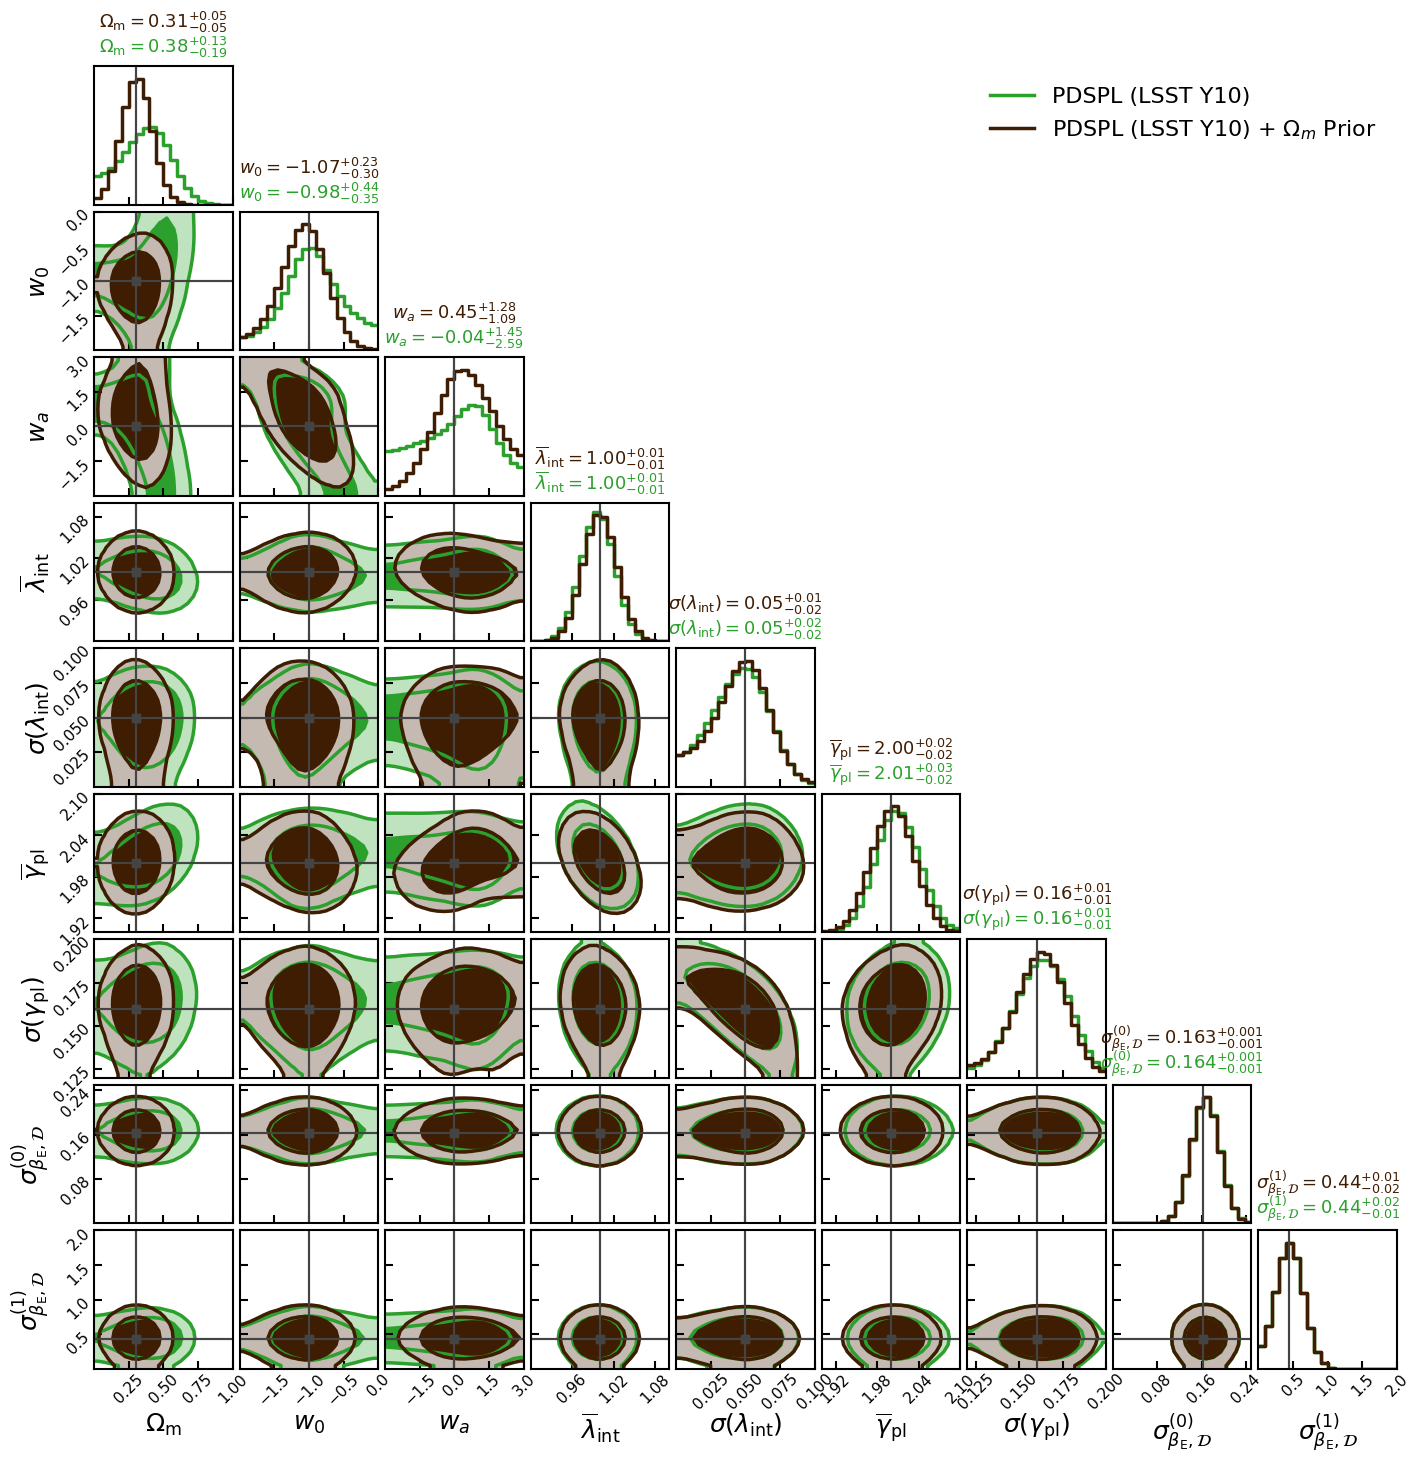

In [9]:

scenarios_to_plot = [
    'lsst_y10',
    'lsst_y10_om_prior'
]


fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=custom_truths, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(14, 14),
    show_multiple_titles=True,
    save_path=FIGURE_DIRECTORY + "/lsst_y10_w0waCDM_free_scatter_forecast.pdf",
    # titles_fontsize=12
)

plt.show()



## Table of Forecast Results

In [10]:
print("\n--- Parameter Summary Table (Median with 16th/84th Percentiles) ---")
print(f"{'Scenario':<45} | {'Parameter':<25} | {'Median':<10} | {'-1σ':<10} | {'+1σ':<10}")
print("-" * 110) 
for key in scenarios.keys():
    sc = scenarios[key]
    if 'samples' not in sc:
        continue
    
    samples = sc['samples']
    scenario_name = sc['name']
    
    for param_idx, param_key in enumerate(param_labels):
        samples_1d = samples[:, param_idx]
        q16, q50, q84 = np.percentile(samples_1d, [16, 50, 84])
        lower_err = q50 - q16
        upper_err = q84 - q50
        
        print(f"{scenario_name:<45} | {param_key:<25} | {q50:<10.3f} | {lower_err:<10.3f} | {upper_err:<10.3f}")

with open('../data/samples/forecast_scenarios_w0waCDM_free_scatter_lsst_y10.pkl', 'wb') as f:
    pickle.dump(scenarios, f)




--- Parameter Summary Table (Median with 16th/84th Percentiles) ---
Scenario                                      | Parameter                 | Median     | -1σ        | +1σ       
--------------------------------------------------------------------------------------------------------------
PDSPL (LSST Y10)                              | $\Omega_m$                | 0.379      | 0.188      | 0.131     
PDSPL (LSST Y10)                              | $w_0$                     | -0.977     | 0.354      | 0.439     
PDSPL (LSST Y10)                              | $w_a$                     | -0.038     | 2.589      | 1.452     
PDSPL (LSST Y10)                              | $\bar{\lambda}_{\rm int}$ | 0.997      | 0.013      | 0.013     
PDSPL (LSST Y10)                              | $\sigma({\lambda}_{\rm int})$ | 0.047      | 0.021      | 0.016     
PDSPL (LSST Y10)                              | $\bar{\gamma}_{\rm pl}$   | 2.008      | 0.022      | 0.026     
PDSPL (LSST Y10)         

## Experiment 1 - Effect of Photometric Redshift Uncertainties on LSST Y10

In [11]:
# scenarios_lsst_y10_z_err = {}

# for rel_z_error in [0.00, 0.01, 0.02, 0.03, 0.05]:
#     key = 'lsst_y10'
#     key_long = key + f"_z_error_{rel_z_error:.2f}"
#     scenarios_lsst_y10_z_err[key_long] = {
#         'name': f"PDSPL ({pdspl_samples[key]['name']})" + f" $\\sigma_z = {rel_z_error:.2f}(1 + z)$",
#         'down_sampling': len(pdspl_samples[key]['pairs_analysis']['pairs_table']) / 200, 
#         'num_lenses': len(pdspl_samples[key]['pairs_analysis']['pairs_table']),
#         'color': pdspl_samples[key]['color'],
#         'coeffs': pdspl_samples[key]['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs'],
#         'pairs_table': pdspl_samples[key]['pairs_analysis']['pairs_table'],
#         'pairs_table_with_errors': pdspl_samples[key]['pairs_analysis']['pairs_table_with_errors'],
#         'redshift_error_rel': rel_z_error,
#         'backend_path': None
#     }

# print("\n--- Generating Mock Datasets for Redshift Experiment ---")
# for key in scenarios_lsst_y10_z_err.keys():
#     sc = scenarios_lsst_y10_z_err[key]
#     num_samples = int(sc['num_lenses'] / sc['down_sampling'])
#     kwargs_list = []

#     pairs_table = sc['pairs_table']
#     pairs_table_with_errors = sc['pairs_table_with_errors']
#     coeffs = sc['coeffs']
#     random_indices = np.random.choice(len(pairs_table), size=num_samples, replace=False)
    
#     for i in random_indices:
#         z_lens = pairs_table["z_D"][i]
#         z1 = pairs_table["z_S1"][i]
#         z2 = pairs_table["z_S2"][i]
        
#         dissimilarity = pairs_table_with_errors['dissimilarity'][i]
#         sigma_beta_intrinsic = np.polyval(coeffs, dissimilarity)
        
#         sigma_beta_meas, sigma_beta_los = 0.01, 0.01
#         sigma_meas_rel = np.sqrt(sigma_beta_meas**2 + sigma_beta_los**2)
        
#         kwargs_list.append(draw_lens_from_given_zs(
#             z_lens=z_lens, z1=z1, z2=z2,
#             lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
#             gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
#             sigma_beta_intrinsic=sigma_beta_intrinsic, 
#             sigma_meas_rel=sigma_meas_rel,
#             dissimilarity=dissimilarity,
#             down_sampling=sc['down_sampling'], 
#             with_noise=False,
#             cosmo=cosmo_true, 
#             redshift_error_rel=sc['redshift_error_rel']
#         ))
            
#     sc['kwargs_list'] = kwargs_list

# print("\n--- Starting MCMC Samplers for Redshift Experiment ---")
# for key in scenarios_lsst_y10_z_err.keys():
#     sc = scenarios_lsst_y10_z_err[key]
#     print(f"Running Inference for: {sc['name']}")
    
#     samples, labels = run_dspl_inference(
#         sc['kwargs_list'],
#         n_walkers=64,
#         n_steps=2000, 
#         n_burn=500,
#         initial_guess=initial_guess_sc,
#         fixed_params=fixed_params_sc,
#         initial_scatter=my_spreads,
#         priors=my_priors,
#         backend_path=sc['backend_path']
#     )
    
#     sc['samples'] = samples

# scenarios_to_plot_err = [
#     'lsst_y10_z_error_0.05',
#     'lsst_y10_z_error_0.03',
#     'lsst_y10_z_error_0.02',
#     'lsst_y10_z_error_0.01',
#     'lsst_y10_z_error_0.00',
# ]

# custom_colors_dict_err = {
#     'lsst_y10_z_error_0.00': '#3b4cc0',
#     'lsst_y10_z_error_0.01': '#8cb0e7',
#     'lsst_y10_z_error_0.02': '#dddddd',
#     'lsst_y10_z_error_0.03': '#f2967f',
#     'lsst_y10_z_error_0.05': '#b40426',
# }

# fig = plot_dspl_corner(
#     scenarios=scenarios_lsst_y10_z_err, 
#     truth=truth, 
#     fixed_params=fixed_params, 
#     scenarios_to_plot=scenarios_to_plot_err,
#     custom_ranges=custom_ranges,
#     latex_labels=latex_labels,
#     figsize=(14, 14),
#     show_multiple_titles=True,
#     custom_colors_dict=custom_colors_dict_err
# )

# plt.show()